# Tier-C (part 2) — Hyperparameter Optimization + Class-imbalance study

Two studies, both **dual-GPU** and **restart-safe from S3**:

**A. Optuna HPO** — tunes the headline models (ConvMambaLOB, MambaLOB, TLOB) on NIFTY $k{=}100$. Dual-GPU by
running one *model's* study per GPU (two models search concurrently; no SQLite write contention). Resumable
for free: each study uses an on-disk SQLite DB that we pull from / push to S3, and Optuna's `load_if_exists`
skips trials already in the DB. A killed session just re-pulls the DB and continues.

**B. Class-imbalance study** — on the best model (ConvMambaLOB), compares loss/sampling strategies
(`weighted_ce`, `plain_ce`, `focal`, `label_smoothing`, `balanced_sampling`) by their effect on macro-$F_1$
and **per-class recall** of the minority directional classes. Reuses the dual-GPU sharded runner with the
*fixed* per-run S3 resume (pulls merged **and** shard CSVs — the bug that re-ran everything in the Tier-B run
is fixed here; see the note in cell 8).

Setup: **GPU T4 x2**; secrets `GH_PAT`, `AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`.
S3 layout: `experiments/hpo/` and `experiments/imbalance/`.


## 1. Runtime check (expect 2 GPUs)

In [1]:
import torch, platform
print("Python:", platform.python_version(), "| Torch:", torch.__version__)
n = torch.cuda.device_count()
print(f"GPUs visible: {n}")
for i in range(n):
    print(f"  cuda:{i} = {torch.cuda.get_device_name(i)}")
assert n >= 1, "Enable GPU. For 2x throughput choose 'GPU T4 x2'."

Python: 3.12.13 | Torch: 2.10.0+cu128
GPUs visible: 2
  cuda:0 = Tesla T4
  cuda:1 = Tesla T4


## 2. Get the project code (GH_PAT secret)

In [2]:
import sys, subprocess, pathlib
REPO_URL = "https://github.com/rajjoseph48/nse-lob-capstone.git"
REPO_DIR = "nse-lob-capstone"
def _get_secret(name):
    try:
        from kaggle_secrets import UserSecretsClient
        v = UserSecretsClient().get_secret(name)
        if v: return v
    except Exception: pass
    try:
        from google.colab import userdata
        v = userdata.get(name)
        if v: return v
    except Exception: pass
    import os
    return os.environ.get(name, "")
GITHUB_TOKEN = _get_secret("GH_PAT")
def add_modeling(base):
    base = pathlib.Path(base)
    for cand in (base / "modeling", base):
        if (cand / "models.py").exists():
            sys.path.insert(0, str(cand.resolve())); return str(cand.resolve())
    return None
MODELING_DIR = None
for c in (".", REPO_DIR, "/kaggle/working/" + REPO_DIR, "/content/" + REPO_DIR):
    MODELING_DIR = add_modeling(c)
    if MODELING_DIR: break
if not MODELING_DIR:
    url = REPO_URL.replace("https://", f"https://{GITHUB_TOKEN}@") if GITHUB_TOKEN else REPO_URL
    subprocess.run(["git", "clone", "--depth", "1", url], check=True)
    MODELING_DIR = add_modeling(REPO_DIR)
print("modeling/ dir:", MODELING_DIR)

modeling/ dir: /kaggle/working/nse-lob-capstone/modeling


## 3. Install deps (Mamba kernel + boto3 + optuna)

In [3]:
import subprocess, sys
def pipq(*pkgs): subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
pipq("boto3", "optuna", "scipy")
pipq("ninja", "packaging", "setuptools", "wheel")
pipq("--no-build-isolation", "causal-conv1d")
pipq("--no-build-isolation", "mamba-ssm")
import optuna
print("optuna", optuna.__version__)
try:
    import mamba_ssm; print("mamba-ssm", mamba_ssm.__version__)
except Exception as e:
    print("mamba-ssm NOT importable -> pure-PyTorch fallback:", repr(e))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.7/327.7 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 46.8 MB/s eta 0:00:00
optuna 4.8.0
mamba-ssm 2.3.2.post1


## 4. Download NSE data from S3

In [4]:
import os, boto3, pathlib

from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("AWS_ACCESS_KEY_ID")
secret_value_1 = user_secrets.get_secret("AWS_SECRET_ACCESS_KEY")

os.environ["AWS_ACCESS_KEY_ID"] = secret_value_0 #_get_secret("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = secret_value_1 # _get_secret("AWS_SECRET_ACCESS_KEY")


BUCKET, PREFIX, REGION = "lob-capstone-data", "lob-data/dhan/", "ap-south-2"
DATA_DIR_NSE = "nse_data/dhan"; pathlib.Path(DATA_DIR_NSE).mkdir(parents=True, exist_ok=True)
s3 = boto3.client("s3", region_name=REGION)
n = 0
for o in s3.list_objects_v2(Bucket=BUCKET, Prefix=PREFIX).get("Contents", []):
    if o["Size"] == 0: continue
    dst = os.path.join(DATA_DIR_NSE, o["Key"].split("/")[-1])
    if not os.path.exists(dst): s3.download_file(BUCKET, o["Key"], dst)
    n += 1
print(f"{n} parquet files in {DATA_DIR_NSE}")

28 parquet files in nse_data/dhan


# Part A — Optuna hyperparameter search
## 5. HPO config + resume (pull existing study DBs from S3)

In [5]:
import pathlib
from nbenv import s3_client, s3_pull_area

HPO_MODELS = ["convmambalob", "mambalob"]   # headline models to tune , "tlob"
HPO_SYMBOL, HPO_H, HPO_FS = "NIFTY", 100, "all"
N_TRIALS = 20                                        # trials per model (TPE)
HPO_EPOCHS = 12                                      # short budget per trial
HPO_AREA = "hpo"
pathlib.Path("hpo").mkdir(exist_ok=True)

JOBS = [{"model": m, "study": f"{m}_{HPO_SYMBOL}_h{HPO_H}",
         "db": f"hpo/{m}_{HPO_SYMBOL}_h{HPO_H}.db"} for m in HPO_MODELS]

# resume: pull any existing DBs (Optuna load_if_exists then skips completed trials)
_s3 = s3_client()
for j in JOBS:
    got = s3_pull_area(_s3, pathlib.Path(j["db"]), HPO_AREA)
    print(f"{j['study']}: {'resumed from S3' if got else 'fresh study'}")
JOBS

   pulled s3://lob-capstone-data/experiments/hpo/results/convmambalob_NIFTY_h100.db (resuming)
convmambalob_NIFTY_h100: resumed from S3
   pulled s3://lob-capstone-data/experiments/hpo/results/mambalob_NIFTY_h100.db (resuming)
mambalob_NIFTY_h100: resumed from S3


[{'model': 'convmambalob',
  'study': 'convmambalob_NIFTY_h100',
  'db': 'hpo/convmambalob_NIFTY_h100.db'},
 {'model': 'mambalob',
  'study': 'mambalob_NIFTY_h100',
  'db': 'hpo/mambalob_NIFTY_h100.db'}]

## 6. Run HPO across both GPUs (one model per GPU) + periodic DB sync to S3
A small scheduler keeps both GPUs busy: it assigns queued model-studies to free GPUs, tails their logs, and
uploads each study DB to S3 every ~2 min and on completion — so a time-out costs at most the trials since the
last sync (and Optuna resumes the rest).

In [ ]:
import os, sys, subprocess, time, torch, pathlib
from nbenv import s3_client, s3_put_area

n_gpus = max(1, torch.cuda.device_count())
RUN_HPO = f"{MODELING_DIR}/run_hpo.py"

def _launch(gpu, job):
    env = dict(os.environ); env["CUDA_VISIBLE_DEVICES"] = str(gpu); env["PYTHONUNBUFFERED"] = "1"
    logf = f"hpo_{job['model']}.log"; fh = open(logf, "w")
    cmd = [sys.executable, "-u", RUN_HPO, "--model", job["model"], "--symbol", HPO_SYMBOL,
           "--horizon", str(HPO_H), "--feature-set", HPO_FS, "--storage", f"sqlite:///{job['db']}",
           "--study-name", job["study"], "--n-trials", str(N_TRIALS), "--epochs", str(HPO_EPOCHS),
           "--data-dir", DATA_DIR_NSE]
    print(f"launched HPO {job['study']} on GPU {gpu}")
    return {"proc": subprocess.Popen(cmd, env=env, stdout=fh, stderr=subprocess.STDOUT),
            "fh": fh, "logf": logf, "pos": 0, "job": job}

queue = list(JOBS); running = {}                      # gpu index -> live handle
last_sync = 0.0
while queue or running:
    # assign any queued study to a free GPU
    for g in range(n_gpus):
        if g not in running and queue:
            running[g] = _launch(g, queue.pop(0))
    # tail logs + reap finished
    for g, h in list(running.items()):
        with open(h["logf"]) as r:
            r.seek(h["pos"]); chunk = r.read(); h["pos"] = r.tell()
        if chunk: print(chunk, end="")
        if h["proc"].poll() is not None:              # finished -> flush, sync DB, free GPU
            with open(h["logf"]) as r: r.seek(h["pos"]); print(r.read(), end="")
            h["fh"].close(); s3_put_area(s3_client(), h["job"]["db"], HPO_AREA)
            print(f"   [{h['job']['study']}] done, DB synced to S3")
            del running[g]
    # periodic DB sync (crash-safety mid-run)
    if time.time() - last_sync > 120:
        for h in running.values():
            if pathlib.Path(h["job"]["db"]).exists():
                s3_put_area(s3_client(), h["job"]["db"], HPO_AREA)
        last_sync = time.time()
    time.sleep(10)
print("\nHPO complete.")

## 7. Best hyperparameters per model

In [7]:
import optuna, json, pandas as pd
from nbenv import s3_client, s3_put_area
rows = []
for j in JOBS:
    st = optuna.load_study(study_name=j["study"], storage=f"sqlite:///{j['db']}")
    rows.append({"model": j["model"], "n_trials": len(st.trials),
                 "best_val_f1": round(st.best_value, 4), **st.best_params})
    print(f"{j['model']:14s} best val_f1={st.best_value:.4f}  {st.best_params}")
best = pd.DataFrame(rows)
best.to_json("hpo/best_params.json", orient="records", indent=2)
best.to_csv("hpo/best_params.csv", index=False)
s3_put_area(s3_client(), "hpo/best_params.json", HPO_AREA)
s3_put_area(s3_client(), "hpo/best_params.csv", HPO_AREA)
print("\nSaved best params to s3://.../experiments/hpo/results/")
best

convmambalob   best val_f1=0.6693  {'lr': 0.00028542696734448373, 'batch_size': 256, 'weight_decay': 6.417406576633353e-05, 'd_model': 64, 'd_state': 16, 'n_layers': 3}
mambalob       best val_f1=0.6753  {'lr': 0.00024112533976309325, 'batch_size': 128, 'weight_decay': 0.0005528660219689535, 'd_model': 32, 'd_state': 32, 'n_layers': 1}
   ^ s3://lob-capstone-data/experiments/hpo/results/best_params.json
   ^ s3://lob-capstone-data/experiments/hpo/results/best_params.csv

Saved best params to s3://.../experiments/hpo/results/


,model,n_trials,best_val_f1,lr,batch_size,weight_decay,d_model,d_state,n_layers
0,convmambalob,23,0.6693,0.000285,256,0.000064,64,16,3
1,mambalob,26,0.6753,0.000241,128,0.000553,32,32,1


# Part B — Class-imbalance study
## 8. Strategy grid + resume (FIXED per-run S3 resume)
The fix vs the Tier-B run: cell pulls the merged CSV **and** each per-shard CSV that `runner.run_one` pushes
after every run, so an interrupted session resumes at per-run granularity (the Tier-B notebook on Kaggle ran
a stale cell that pulled only the merged CSV — written only at the final merge — so it re-ran everything).
The resume key here includes `strategy`.

In [8]:
import json, pathlib, pandas as pd
from nbenv import s3_client, s3_pull_area

AREA = "imbalance"
MERGED = pathlib.Path("results/imbalance.csv")
BEST_MODEL = "convmambalob"
STRATEGIES = ["weighted_ce", "plain_ce", "focal", "label_smoothing", "balanced_sampling"]
SYMBOL, HORIZONS = "NIFTY", [10, 100]               # h100 = worst imbalance; h10 for contrast

GRID = []
for strat in STRATEGIES:
    for h in HORIZONS:
        GRID.append({"model": BEST_MODEL, "symbol": SYMBOL, "feature_set": "all",
                     "horizon": h, "label_scheme": "A", "seed": 0, "strategy": strat})

_s3 = s3_client(); pathlib.Path("results").mkdir(exist_ok=True)
s3_pull_area(_s3, MERGED, AREA)
shard_csvs = [pathlib.Path(f"results/shard{i}.csv") for i in range(2)]
for sc in shard_csvs:
    s3_pull_area(_s3, sc, AREA)
done = set()
for f in [MERGED, *shard_csvs]:
    if f.exists():
        d = pd.read_csv(f)
        if "strategy" not in d.columns: d["strategy"] = "weighted_ce"
        done |= {(r.model, r.symbol, r.feature_set, int(r.horizon), r.label_scheme, int(r.seed), r.strategy)
                 for r in d.itertuples()}
def _key(s):
    return (s["model"], s["symbol"], s["feature_set"], int(s["horizon"]),
            s["label_scheme"], int(s["seed"]), s["strategy"])
todo = [s for s in GRID if _key(s) not in done]
pathlib.Path("runlist.json").write_text(json.dumps(todo))
print(f"grid={len(GRID)} | done={len(done)} | to run this session={len(todo)}")
todo

grid=10 | done=0 | to run this session=10


[{'model': 'convmambalob',
  'symbol': 'NIFTY',
  'feature_set': 'all',
  'horizon': 10,
  'label_scheme': 'A',
  'seed': 0,
  'strategy': 'weighted_ce'},
 {'model': 'convmambalob',
  'symbol': 'NIFTY',
  'feature_set': 'all',
  'horizon': 100,
  'label_scheme': 'A',
  'seed': 0,
  'strategy': 'weighted_ce'},
 {'model': 'convmambalob',
  'symbol': 'NIFTY',
  'feature_set': 'all',
  'horizon': 10,
  'label_scheme': 'A',
  'seed': 0,
  'strategy': 'plain_ce'},
 {'model': 'convmambalob',
  'symbol': 'NIFTY',
  'feature_set': 'all',
  'horizon': 100,
  'label_scheme': 'A',
  'seed': 0,
  'strategy': 'plain_ce'},
 {'model': 'convmambalob',
  'symbol': 'NIFTY',
  'feature_set': 'all',
  'horizon': 10,
  'label_scheme': 'A',
  'seed': 0,
  'strategy': 'focal'},
 {'model': 'convmambalob',
  'symbol': 'NIFTY',
  'feature_set': 'all',
  'horizon': 100,
  'label_scheme': 'A',
  'seed': 0,
  'strategy': 'focal'},
 {'model': 'convmambalob',
  'symbol': 'NIFTY',
  'feature_set': 'all',
  'horizon': 

## 9. Launch shards (dual-GPU, reuses run_shard.py + per-run S3 push)

In [9]:
import os, sys, subprocess, time, torch, pathlib
n_gpus = torch.cuda.device_count(); nshards = max(1, n_gpus)
RUN_SHARD = f"{MODELING_DIR}/run_shard.py"
pathlib.Path("results").mkdir(exist_ok=True)
procs = []
for i in range(nshards):
    env = dict(os.environ); env["CUDA_VISIBLE_DEVICES"] = str(i); env["PYTHONUNBUFFERED"] = "1"
    logf = f"shard{i}.log"; fh = open(logf, "w")
    cmd = [sys.executable, "-u", RUN_SHARD, "--runlist", "runlist.json", "--shard", str(i),
           "--nshards", str(nshards), "--data-dir", DATA_DIR_NSE, "--out", f"results/shard{i}.csv",
           "--ckpt-dir", "checkpoints/imb", "--area", "imbalance", "--epochs", "20"]
    procs.append([subprocess.Popen(cmd, env=env, stdout=fh, stderr=subprocess.STDOUT), fh, logf, 0])
    print(f"launched shard {i} on CUDA_VISIBLE_DEVICES={i}")
while any(p[0].poll() is None for p in procs):
    for p in procs:
        with open(p[2]) as r: r.seek(p[3]); chunk = r.read(); p[3] = r.tell()
        if chunk: print(chunk, end="")
    time.sleep(10)
for p in procs:
    p[1].close()
    with open(p[2]) as r: r.seek(p[3]); print(r.read(), end="")
print("\nexit codes:", [p[0].poll() for p in procs])

launched shard 0 on CUDA_VISIBLE_DEVICES=0
launched shard 1 on CUDA_VISIBLE_DEVICES=1
Using device: cuda
[shard 0/2] device=cuda | CUDA_VISIBLE_DEVICES=0 | 5 runs

[shard 0] run 1/5: {'model': 'convmambalob', 'symbol': 'NIFTY', 'feature_set': 'all', 'horizon': 10, 'label_scheme': 'A', 'seed': 0, 'strategy': 'weighted_ce'}
  convmambalob_NIFTY_all_h10_s0  | device=cuda

Loading NSE | root=NIFTY (front-month) | horizon=k10 | seq_len=100 | alpha=1e-05
  Train dates (15): 20260512..20260604
  Test  dates (6): ['20260605', '20260608', '20260609', '20260610', '20260611', '20260612']
    20260514 NIFTY: dropped 1 outlier rows
Using device: cuda
[shard 1/2] device=cuda | CUDA_VISIBLE_DEVICES=1 | 5 runs

[shard 1] run 1/5: {'model': 'convmambalob', 'symbol': 'NIFTY', 'feature_set': 'all', 'horizon': 100, 'label_scheme': 'A', 'seed': 0, 'strategy': 'weighted_ce'}
  convmambalob_NIFTY_all_h100_s0  | device=cuda

Loading NSE | root=NIFTY (front-month) | horizon=k100 | seq_len=100 | alpha=1e-05
  T

## 10. Merge shard CSVs + push to S3

In [10]:
import glob, pandas as pd
from nbenv import s3_client, s3_put_area
keys = ["model", "symbol", "feature_set", "horizon", "label_scheme", "seed", "strategy"]
frames = [pd.read_csv(MERGED)] if MERGED.exists() else []
frames += [pd.read_csv(f) for f in glob.glob("results/shard*.csv")]
alldf = pd.concat(frames, ignore_index=True).drop_duplicates(subset=keys, keep="last") if frames else pd.DataFrame()
alldf.to_csv(MERGED, index=False)
s3_put_area(s3_client(), MERGED, AREA)
print(f"merged {len(alldf)} rows -> {MERGED}")
alldf.sort_values(keys)

   ^ s3://lob-capstone-data/experiments/imbalance/results/imbalance.csv
merged 10 rows -> results/imbalance.csv


,model,symbol,feature_set,label_scheme,horizon,seed,strategy,n_features,n_params,best_epoch,...,test_macro_f1,test_weighted_f1,test_mcc,recall_down,recall_stat,recall_up,baseline_majority_wf1,baseline_stat_wf1,baseline_random_wf1,train_time_s
4,convmambalob,NIFTY,all,A,10,0,balanced_sampling,66,143735,2,...,0.5196,0.5387,0.2937,0.5651,0.3961,0.5982,0.2091,0.0912,0.3493,1886.6
2,convmambalob,NIFTY,all,A,10,0,focal,66,143735,3,...,0.5245,0.5417,0.2999,0.5714,0.4473,0.5590,0.2091,0.0912,0.3493,2245.1
3,convmambalob,NIFTY,all,A,10,0,label_smoothing,66,143735,3,...,0.5231,0.5421,0.2989,0.5805,0.4116,0.5783,0.2091,0.0912,0.3493,2255.4
1,convmambalob,NIFTY,all,A,10,0,plain_ce,66,143735,4,...,0.4993,0.5306,0.2986,0.6354,0.2087,0.6791,0.2091,0.0912,0.3493,2627.4
0,convmambalob,NIFTY,all,A,10,0,weighted_ce,66,143735,3,...,0.5247,0.5443,0.3030,0.6264,0.3886,0.5600,0.2091,0.0912,0.3493,2245.7
9,convmambalob,NIFTY,all,A,100,0,balanced_sampling,66,143735,1,...,0.4432,0.5779,0.2852,0.5309,0.3958,0.5171,0.3017,0.0057,0.4507,1506.3
7,convmambalob,NIFTY,all,A,100,0,focal,66,143735,1,...,0.4814,0.6464,0.3571,0.6515,0.1076,0.6870,0.3017,0.0057,0.4507,1505.3
8,convmambalob,NIFTY,all,A,100,0,label_smoothing,66,143735,1,...,0.3969,0.5103,0.2699,0.3427,0.6315,0.4780,0.3017,0.0057,0.4507,1508.7
6,convmambalob,NIFTY,all,A,100,0,plain_ce,66,143735,1,...,0.4415,0.6259,0.3435,0.5700,0.0000,0.8007,0.3017,0.0057,0.4507,1505.5
5,convmambalob,NIFTY,all,A,100,0,weighted_ce,66,143735,1,...,0.4749,0.6266,0.3354,0.5401,0.2173,0.7055,0.3017,0.0057,0.4507,1493.0


## 11. Findings — which strategy best recovers the minority directional classes?
Imbalance hurts the Down/Up classes (macro-$F_1$ << weighted-$F_1$). The win condition is *higher macro-$F_1$
and higher Down/Up recall* without collapsing accuracy.

convmambalob  NIFTY  k=10
                   test_weighted_f1  test_macro_f1  recall_down  recall_stat  recall_up
strategy                                                                               
weighted_ce                  0.5443         0.5247       0.6264       0.3886     0.5600
plain_ce                     0.5306         0.4993       0.6354       0.2087     0.6791
focal                        0.5417         0.5245       0.5714       0.4473     0.5590
label_smoothing              0.5421         0.5231       0.5805       0.4116     0.5783
balanced_sampling            0.5387         0.5196       0.5651       0.3961     0.5982

Δ macro-F1 vs weighted_ce baseline:
strategy
weighted_ce          0.0000
plain_ce            -0.0254
focal               -0.0002
label_smoothing     -0.0016
balanced_sampling   -0.0051
convmambalob  NIFTY  k=100
                   test_weighted_f1  test_macro_f1  recall_down  recall_stat  recall_up
strategy                                                 

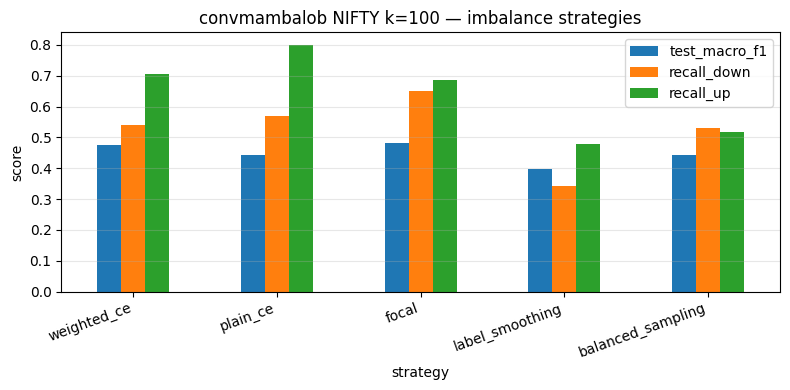

In [11]:
import pandas as pd, matplotlib.pyplot as plt
res = pd.read_csv(MERGED)
res = res[res.model == BEST_MODEL]
ORDER = ["weighted_ce", "plain_ce", "focal", "label_smoothing", "balanced_sampling"]
for h in sorted(res.horizon.unique()):
    sub = res[res.horizon == h].set_index("strategy").reindex(ORDER)
    print("=" * 64, f"\n{BEST_MODEL}  {SYMBOL}  k={h}\n" + "=" * 64)
    cols = ["test_weighted_f1", "test_macro_f1", "recall_down", "recall_stat", "recall_up"]
    print(sub[cols].round(4).to_string())
    base = sub.loc["weighted_ce", "test_macro_f1"]
    print(f"\nΔ macro-F1 vs weighted_ce baseline:")
    print((sub["test_macro_f1"] - base).round(4).to_string())

# bar plot of macro-F1 by strategy (k=100)
sub = res[res.horizon == max(res.horizon)].set_index("strategy").reindex(ORDER)
ax = sub[["test_macro_f1", "recall_down", "recall_up"]].plot.bar(figsize=(8, 4))
ax.set(title=f"{BEST_MODEL} {SYMBOL} k={max(res.horizon)} — imbalance strategies",
       ylabel="score"); ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig("results/fig_imbalance.png", dpi=150, bbox_inches="tight")
from nbenv import s3_client, s3_put_area
s3_put_area(s3_client(), "results/fig_imbalance.png", AREA); plt.show()

## 12. Summary
- **HPO** (Part A): best hyperparameters per model are on S3 at `experiments/hpo/results/best_params.csv`.
  Re-train the headline configs with these for the final report numbers (or feed them into the Tier-C
  multi-seed notebook by overriding the model kwargs).
- **Imbalance** (Part B): the strategy table (`experiments/imbalance/results/imbalance.csv`) shows whether
  focal / sampling / label-smoothing beat the default class-weighted CE on macro-$F_1$ and minority-class
  recall. Use the winner in the final model and the cost-aware backtest.
- Both studies are dual-GPU and resume from S3 (HPO via the Optuna DB; imbalance via the fixed per-run CSV
  resume), so long runs survive Kaggle time-outs.
